**Program**: 4_PISA_Visualizations <br>
**Group**: Spring 2025, Data Mining, Final Project, Group 11<br>
**Group Members**: Sean Fitzgerald, Nick Mobus, Vanessa Thorsten<br>
**Description**: This program reads in the analysis dataset dfCOG.csv, which includes country level data from the PISA student testing, SES, student questionnaire, as well as GDP and percent GDP spent on education by country. Data are explored and data visualizations are provided for the dataset.<br>
**Program History/Modifications**:<br>
03/17/2025    Initial Version

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dfpisa = pd.read_csv("dfCOG.csv")
dfpisa=dfpisa.drop(['Unnamed: 0'], axis = 1)
dfpisa.head()

,CNTRYID,country,math_all_mean,math_10th_mean,math_25th_mean,math_50th_mean,math_75th_mean,math_90th_mean,math_diff_90_10,math_diff_90_10_se,...,high_life_satisfaction,high_life_satisfaction_cat,high_growth_mindset_cat,low_growth_mindset_cat,high_grit,high_grit_cat,low_grit,low_grit_cat,high_love_learn,high_love_learn_cat
0,100,Bulgaria,417,298,346,411,483,549,251,6.8,...,0.5293,>=50%,High,Medium,0.6108,>=60%,0.2247,20-30%,0.7403,<75%
1,116,Cambodia,336,244,288,336,383,428,184,4.6,...,0.5879,>=50%,NaN,NaN,NaN,NaN,NaN,NaN,0.8379,>=75%
2,124,Canada,497,375,430,496,562,619,244,2.7,...,NaN,NaN,Medium,Medium,0.6175,>=60%,0.1324,10-19%,0.7126,<75%
3,152,Chile,412,315,358,409,464,514,198,3.3,...,0.3990,<50%,High,Medium,0.7616,>=60%,0.0819,0-9%,0.7966,>=75%
4,158,Chinese Taipei,547,393,470,554,628,687,294,6.8,...,0.4272,<50%,Medium,Medium,0.7018,>=60%,0.0503,0-9%,0.6278,<75%


In [64]:
dfpisa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Columns: 128 entries, CNTRYID to high_love_learn_cat
dtypes: float64(83), int64(31), object(14)
memory usage: 81.1+ KB


In [65]:
dfpisa["country"].value_counts()

,count
country,
Bulgaria,1
Cambodia,1
Canada,1
Chile,1
Chinese Taipei,1
...,...
United States,1
Uruguay,1
Uzbekistan,1



## **Study questions**:<br>

1. What is the relationship between gross domestic product (**country_gdp**) and  socioeconomic disparities (**ses_all_mean**) with satisfaction with life as a whole among students (**ST016Q01NA_0.0_proportion - ST016Q01NA_10.0_proportion** summarized by **high_life_satisfaction, high_life_satisfaction_cat**)?
2. What factors (including **country_gdp, ses_all_mean**) influence countries meeting the minimum proficiency level (**math_min_proficiency, read_min_proficiency, scie_min_proficiency**) (Sustainable Development Goal 4.1.1)?
3. How does a growth mindset (**ST263Q02JA_1.0_proportion - ST263Q02JA_4.0_proportion**) relate to math (**math_all_mean**), reading (**read_all_mean**) and science(**scie_all_mean**)  proficiency?
4. How does grit (**ST307Q02JA_1.0_proportion-ST307Q02JA_5.0_proportion**), love of learning (**ST301Q10JA_1.0_proportion- ST301Q10JA_5.0_proportion**) and empathy among students (**ST303Q04JA_1.0_proportion-ST303Q04JA_5.0_proportion**) influence Science proficienc (**scie_all_mean**)y?
5. What effect does daily moderate to vigorous exercise (**WB032Q01NA_1.0_proportion-WB032Q01NA_8.0_proportion, WB032Q02NA_1.0_proportion-WB032Q02NA_8.0_proportion**) have on the mental health of students (**WB154Q04HA_1.0_proportion-WB154Q04HA_5.0_proportion,WB154Q09HA_1.0_proportion-WB154Q09HA_5.0_proportion**)?
6. How does total government expenditure on education (**ed_percent_gdp**) influence reading(**read_all_mean**) and math(**math_all_mean**) proficiency?
7. How does food availability (**ST258Q01JA_1.0_proportion-ST258Q01JA_5.0_proportion**) affect student performance generally(**math_all_mean, read_all_mean, scie_all_mean**)?
8. How does literacy leve (**read_all_mean**)l impact student performance in mathematics (**math_all_mean**)?
9. How much of the variation in student performance (**math_all_mean, read_all_mean, scie_all_mean**) is explained by socioeconomic status(**ses_all_mean**)?
10. What impact does socioeconomic status (**ses_all_mean**) have on school attendance (**ST062Q01TA_1.0_proportion-ST062Q01TA_4.0_proportion**), and which has the greater independent impact on academic performance?

#### **Exploratory Data Analysis and Visualizations**<br>

We computed summary statistics (mean, median, variance, skewness, etc.), explored correlations between features, and conducted data similarity and integration analysis, as needed. For each question, we completed visualizations.


In [66]:
#Pull off main continuous variables of interest.
#For the proportions, just look at the first level of each variable
dfpisa_continuous = pd.DataFrame(dfpisa[["math_all_mean", "read_all_mean", "scie_all_mean",
                          "country_gdp", "ses_all_mean",
                          "high_life_satisfaction",
                          "ST263Q02JA_1.0_proportion", "ST307Q02JA_1.0_proportion",
                          "ST303Q04JA_1.0_proportion", "WB032Q01NA_1.0_proportion",
                          "WB032Q02NA_1.0_proportion", "WB154Q04HA_1.0_proportion",
                          "WB154Q09HA_1.0_proportion", "ed_percent_gdp",
                          "ST258Q01JA_1.0_proportion", "ST062Q01TA_1.0_proportion"]])

In [67]:
dfpisa_continuous.describe()

,math_all_mean,read_all_mean,scie_all_mean,country_gdp,ses_all_mean,high_life_satisfaction,ST263Q02JA_1.0_proportion,ST307Q02JA_1.0_proportion,ST303Q04JA_1.0_proportion,WB032Q01NA_1.0_proportion,WB032Q02NA_1.0_proportion,WB154Q04HA_1.0_proportion,WB154Q09HA_1.0_proportion,ed_percent_gdp,ST258Q01JA_1.0_proportion,ST062Q01TA_1.0_proportion
count,81.000000,81.000000,81.000000,80.000000,80.000000,73.000000,75.000000,72.000000,71.000000,15.000000,15.000000,14.000000,14.000000,81.000000,66.000000,80.000000
mean,437.654321,435.024691,446.864198,40573.125979,-0.357625,0.496700,0.147184,0.066150,0.036546,0.160667,0.226533,0.519550,0.394650,4.510049,0.841344,0.770824
std,58.190884,56.120178,55.737724,26573.328769,0.583400,0.102424,0.045934,0.031939,0.018870,0.070083,0.054681,0.090818,0.100701,1.154718,0.112029,0.154633
min,336.000000,329.000000,347.000000,5663.121600,-2.010000,0.215000,0.073000,0.018800,0.007000,0.063700,0.138400,0.380700,0.192200,1.275171,0.322500,0.385200
25%,389.000000,386.000000,403.000000,18705.666750,-0.735000,0.429500,0.114850,0.041350,0.025700,0.101200,0.192300,0.453875,0.331450,3.738610,0.795550,0.700325
50%,441.000000,438.000000,447.000000,37492.644500,-0.245000,0.498700,0.136500,0.059300,0.031500,0.161300,0.231800,0.495450,0.387900,4.615470,0.869600,0.807250
75%,483.000000,480.000000,494.000000,56166.665500,0.087500,0.564200,0.175600,0.084700,0.045600,0.205300,0.269100,0.600400,0.459550,5.235860,0.914275,0.901800
max,575.000000,543.000000,561.000000,131864.100000,0.520000,0.748300,0.286500,0.139700,0.085200,0.304200,0.312700,0.673100,0.561200,7.572200,0.974200,0.986400


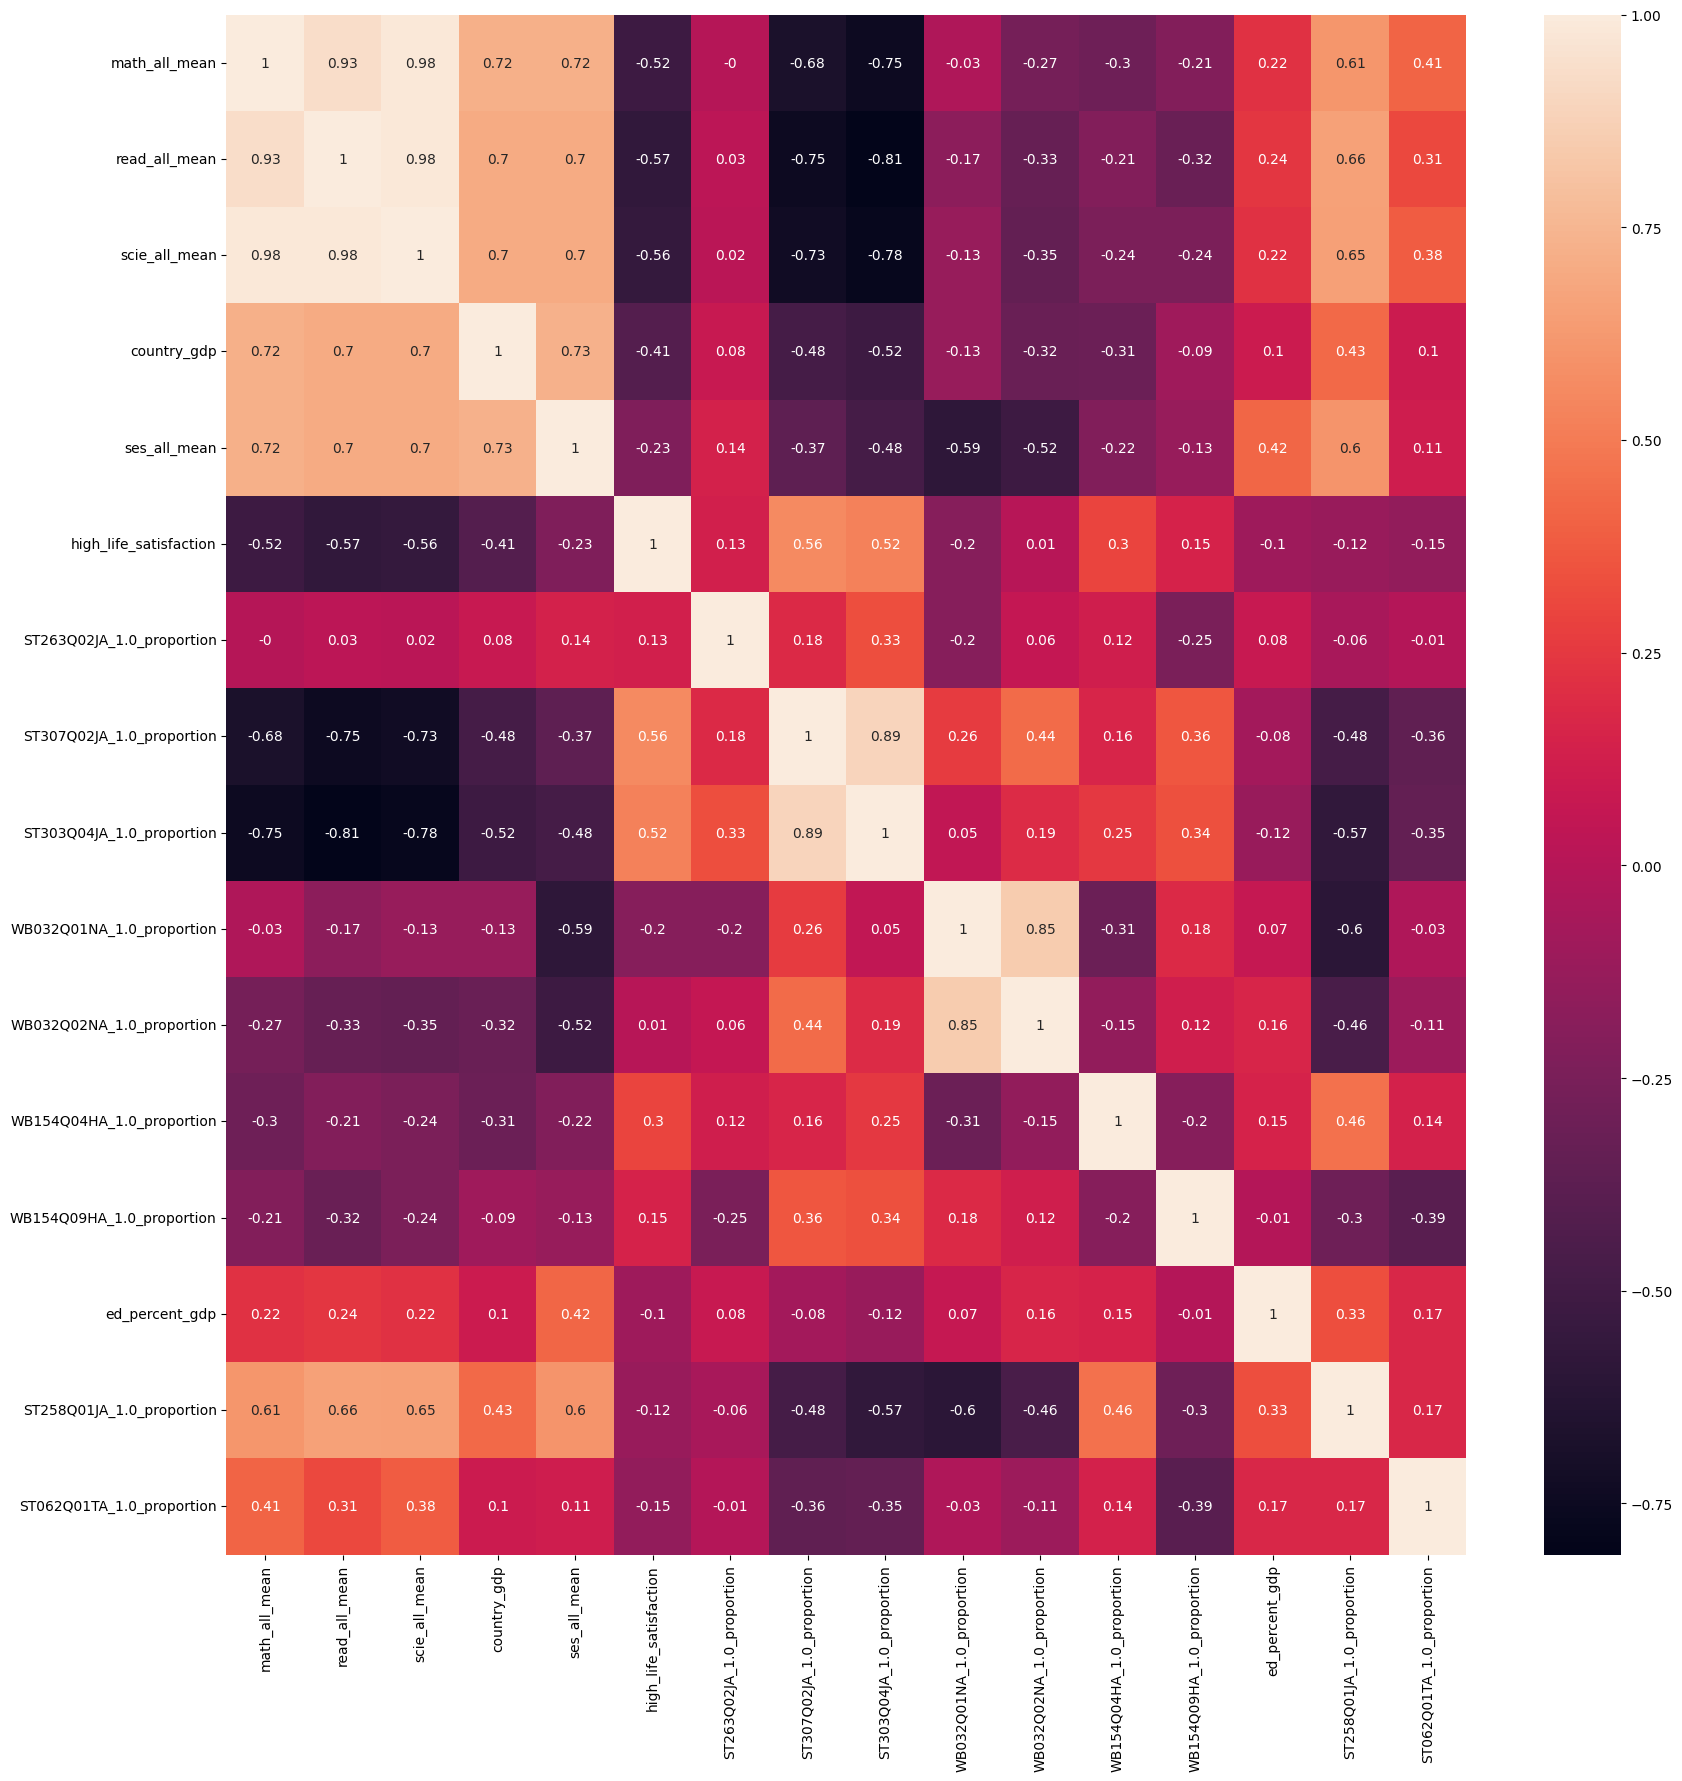

In [68]:
# Pull off variables of interest
cor = dfpisa_continuous.corr().apply(lambda x: round(x,2))

plt.figure(figsize=(20,20))
sns.heatmap(cor, annot=True)
plt.show()

In [69]:
#Check similarities for select variables
from sklearn.metrics.pairwise import cosine_similarity

dfpisa_select_vars = pd.DataFrame(dfpisa[["math_all_mean", "read_all_mean", "scie_all_mean",
                                          "country_gdp", "ses_all_mean"]])

# Drop rows with any NaN values
dfpisa_select_vars_cleaned = dfpisa_select_vars.dropna()

pisa_select_vars_cleaned = np.array(dfpisa_select_vars_cleaned)

pisa_select_vars_cleaned.shape

(79, 5)

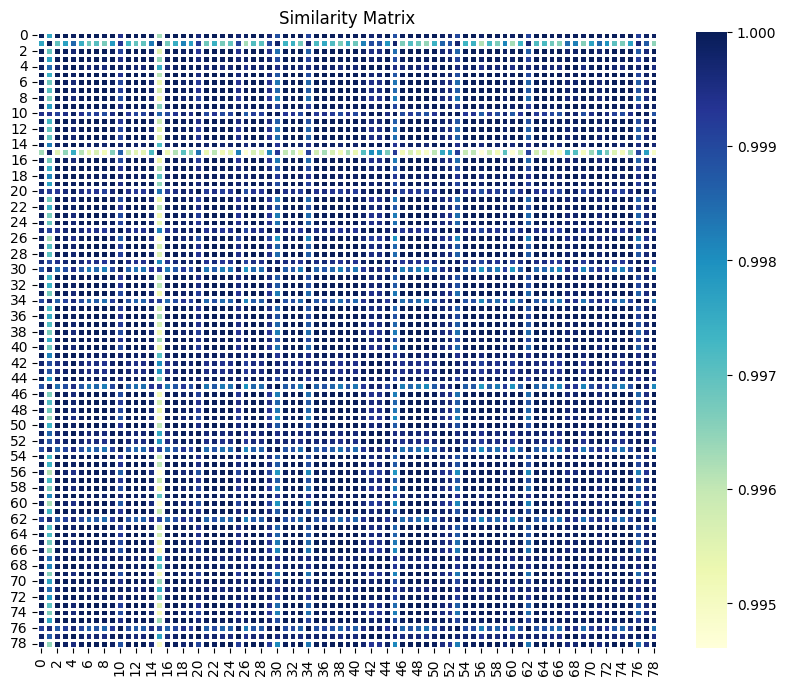

In [70]:
#Function to create the similarity matrix using cosine.
#Input is the data formatted as a numpy array - rows are countries and columns are features
#The cosine similarity matrix is returned.
def create_similarity_matrix(data):
  similarity_matrix = cosine_similarity(data)
  return similarity_matrix

#Call the function with the select variables
similarity_matrix = create_similarity_matrix(pisa_select_vars_cleaned)

# Plot the similarity matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=False, cmap='YlGnBu', linewidths=1)
plt.title('Similarity Matrix')
plt.show()

#### **1. What is the relationship between gross domestic product and socioeconomic disparities with satisfaction with life as a whole among students?**

In [71]:
#Subset to variables of interest
dfpisa_Q1 = pd.DataFrame(dfpisa[["country", "country_gdp", "country_gdp_cat", "ses_all_mean",
                          "high_life_satisfaction", "high_life_satisfaction_cat", "Geo_Region"]])

In [72]:
dfpisa_Q1.describe()

,country_gdp,ses_all_mean,high_life_satisfaction
count,80.000000,80.000000,73.000000
mean,40573.125979,-0.357625,0.496700
std,26573.328769,0.583400,0.102424
min,5663.121600,-2.010000,0.215000
25%,18705.666750,-0.735000,0.429500
50%,37492.644500,-0.245000,0.498700
75%,56166.665500,0.087500,0.564200
max,131864.100000,0.520000,0.748300


In [73]:
dfpisa_Q1.shape

(81, 7)

<ipython-input-74-eeb595dcdada>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=dfpisa_Q1,x='country_gdp', y='high_life_satisfaction', palette='bright')


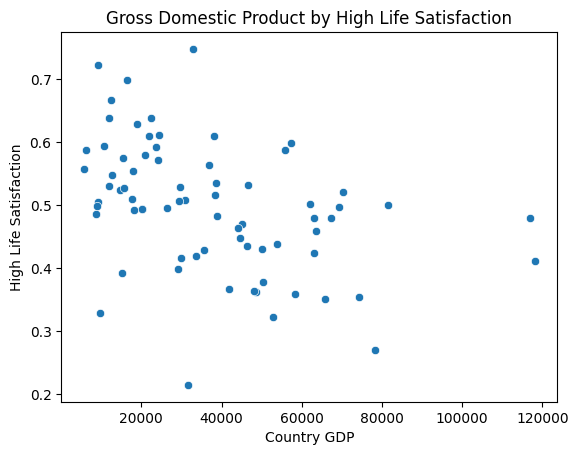

In [74]:
#Figure 1a. gross domestic product by life satisfaction
sns.scatterplot(data=dfpisa_Q1,x='country_gdp', y='high_life_satisfaction', palette='bright')
plt.xlabel('Country GDP')
plt.ylabel('High Life Satisfaction')
plt.title("Gross Domestic Product by High Life Satisfaction")
plt.show()

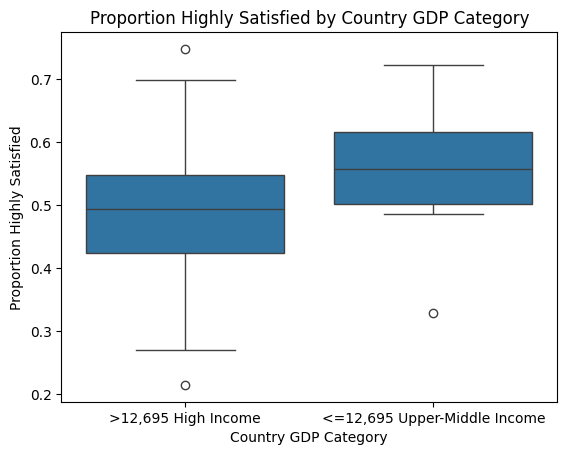

In [75]:
#Figure 1b. gross domestic product by life satisfaction
sns.boxplot(data=dfpisa_Q1, x='country_gdp_cat', y='high_life_satisfaction', dodge=True)
plt.xlabel('Country GDP Category')
plt.ylabel('Proportion Highly Satisfied')
plt.title("Proportion Highly Satisfied by Country GDP Category")
plt.show()

<ipython-input-76-55d5307678d3>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=dfpisa_Q1,x='ses_all_mean', y='high_life_satisfaction', palette='bright')


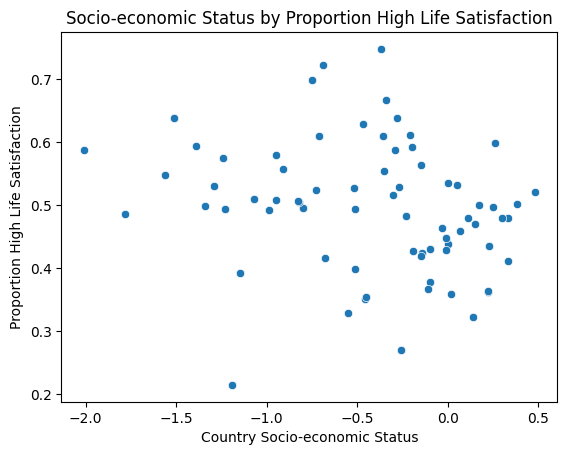

In [76]:
#Figure 1c. SES by life satisfaction
sns.scatterplot(data=dfpisa_Q1,x='ses_all_mean', y='high_life_satisfaction', palette='bright')
plt.xlabel('Country Socio-economic Status')
plt.ylabel('Proportion High Life Satisfaction')
plt.title("Socio-economic Status by Proportion High Life Satisfaction")
plt.show()

#### **2. What factors influence countries meeting the minimum proficiency level (Sustainable Development Goal 4.1.1)?**

In [77]:
#Subset to variables of interest
dfpisa_Q2 = pd.DataFrame(dfpisa[["country", "country_gdp", "country_gdp_cat", "ses_all_mean", "math_all_mean", "read_all_mean", "scie_all_mean",
                          "high_life_satisfaction", "high_life_satisfaction_cat",
                          "math_min_proficiency", "read_min_proficiency", "scie_min_proficiency"]])

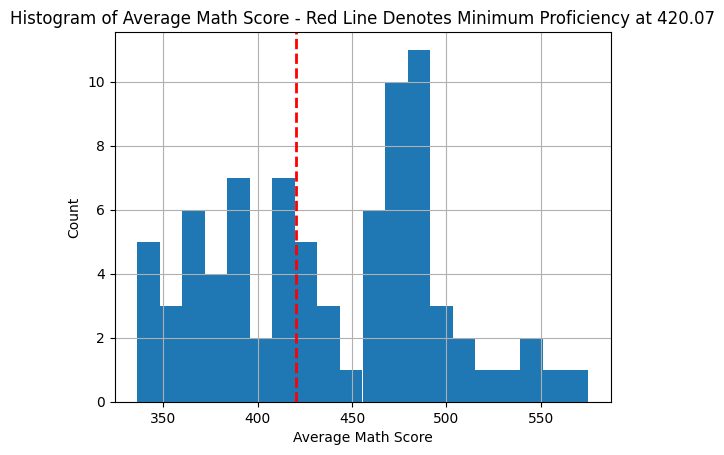

In [78]:
#Figure 2a. math scores

# Create a figure and axes
fig, ax = plt.subplots()

# Draw a vertical line at x = 2
ax.axvline(x=420.07, color='r', linestyle='--', linewidth=2)

dfpisa_Q2['math_all_mean'].hist(bins=20)
plt.xlabel('Average Math Score')
plt.ylabel('Count')
plt.title("Histogram of Average Math Score - Red Line Denotes Minimum Proficiency at 420.07")
plt.show()

In [79]:
dfpisa_Q2['math_min_proficiency'].value_counts()

,count
math_min_proficiency,
Met minimum proficiency,47
Below minimum proficiency,34


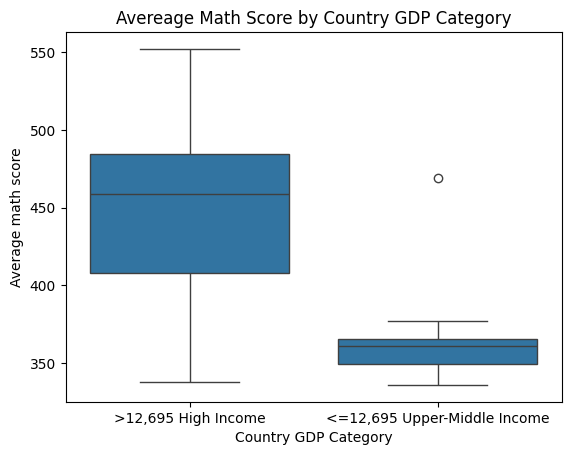

In [80]:
#Figure 2b. math scores by gross domestic product and life satisfaction
sns.boxplot(data=dfpisa_Q2, x='country_gdp_cat', y='math_all_mean', dodge=True)
plt.xlabel('Country GDP Category')
plt.ylabel('Average math score')
plt.title("Avereage Math Score by Country GDP Category")
plt.show()

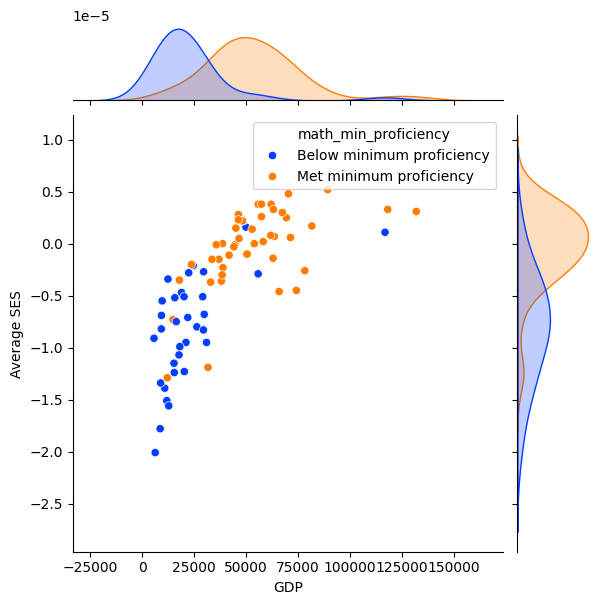

In [81]:
#Figure 2c
sns.jointplot(data=dfpisa_Q2, x='country_gdp',y='ses_all_mean', hue='math_min_proficiency', palette='bright')
plt.xlabel('GDP')
plt.ylabel('Average SES')
#plt.title("Minimum proficiency in math by country economic factors")

plt.show()

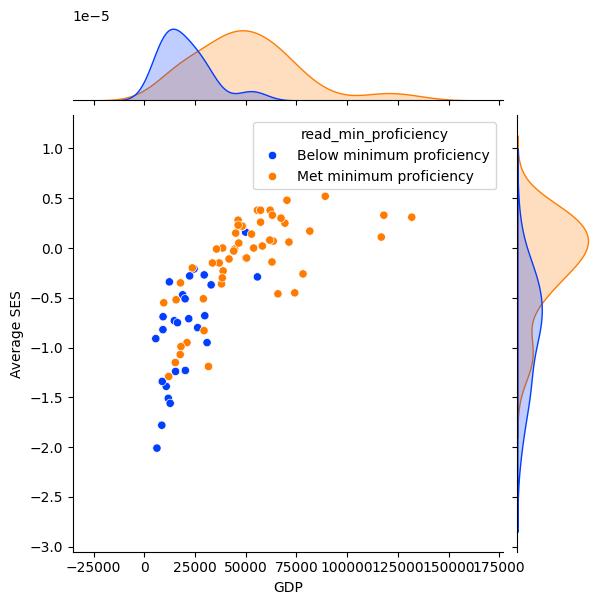

In [82]:
#Figure 2d
sns.jointplot(data=dfpisa_Q2, x='country_gdp',y='ses_all_mean', hue='read_min_proficiency', palette='bright')
plt.xlabel('GDP')
plt.ylabel('Average SES')
#plt.title("Minimum proficiency in reading by country economic factors")

plt.show()

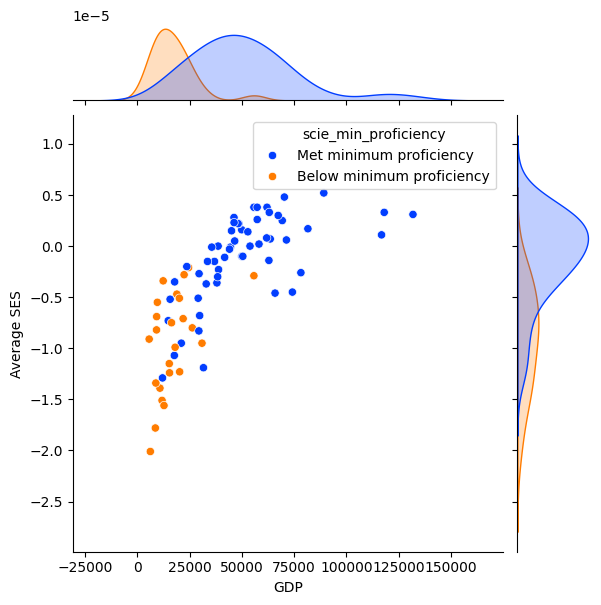

In [83]:
#Figure 2e
sns.jointplot(data=dfpisa_Q2, x='country_gdp',y='ses_all_mean', hue='scie_min_proficiency', palette='bright')
plt.xlabel('GDP')
plt.ylabel('Average SES')
#plt.title("Minimum proficiency in science by country economic factors")

plt.show()

#### **3. How does a growth mindset relate to math, reading and science proficiency?**


In [84]:
#Subset to variables of interest
dfpisa_Q3 = pd.DataFrame(dfpisa[["country", "ST263Q02JA_1.0_proportion", "ST263Q02JA_2.0_proportion", "ST263Q02JA_3.0_proportion",
                          "ST263Q02JA_4.0_proportion", "math_all_mean", "read_all_mean", "scie_all_mean",
                          'high_growth_mindset_cat', 'low_growth_mindset_cat']])

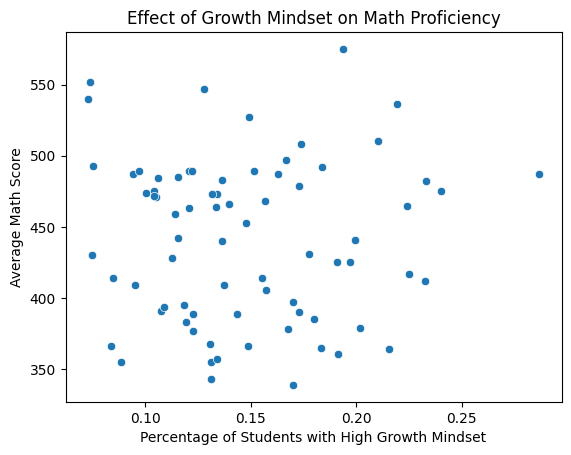

In [85]:
sns.scatterplot(data=dfpisa_Q3,x='ST263Q02JA_1.0_proportion', y='math_all_mean')
plt.xlabel('Percentage of Students with High Growth Mindset')
plt.ylabel('Average Math Score')
plt.title("Effect of Growth Mindset on Math Proficiency")
plt.show()

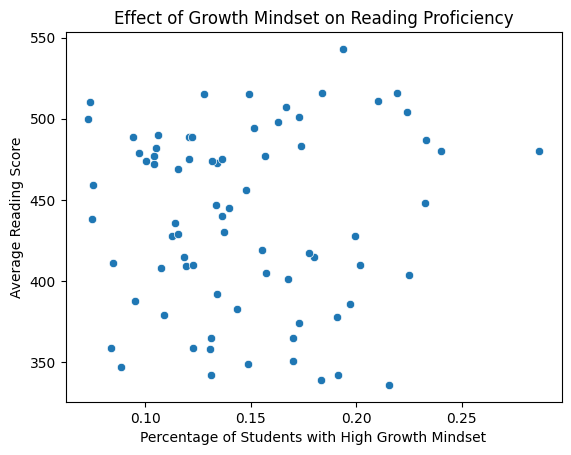

In [86]:
sns.scatterplot(data=dfpisa_Q3,x='ST263Q02JA_1.0_proportion', y='read_all_mean')
plt.xlabel('Percentage of Students with High Growth Mindset')
plt.ylabel('Average Reading Score')
plt.title("Effect of Growth Mindset on Reading Proficiency")
plt.show()

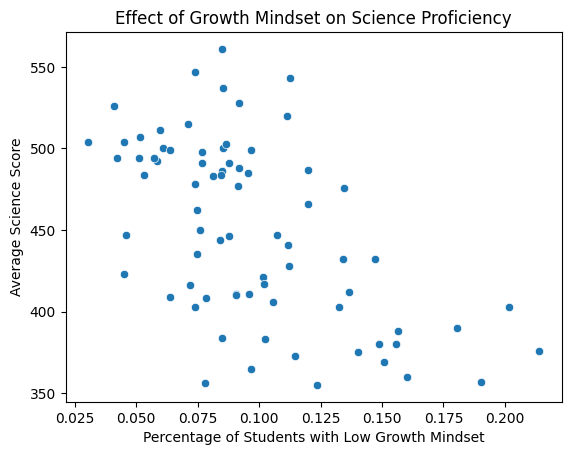

In [87]:
sns.scatterplot(data=dfpisa_Q3,x='ST263Q02JA_4.0_proportion', y='scie_all_mean')
plt.xlabel('Percentage of Students with Low Growth Mindset')
plt.ylabel('Average Science Score')
plt.title("Effect of Growth Mindset on Science Proficiency")
plt.show()

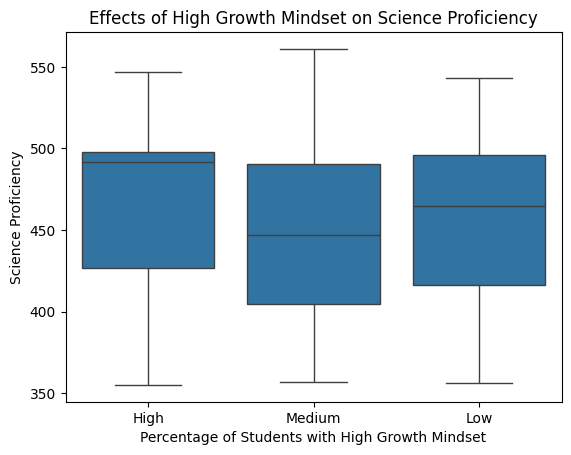

In [88]:
sns.boxplot(data=dfpisa_Q3,x='high_growth_mindset_cat', y='scie_all_mean')
plt.xlabel('Percentage of Students with High Growth Mindset')
plt.ylabel('Science Proficiency')
plt.title("Effects of High Growth Mindset on Science Proficiency")
plt.show()

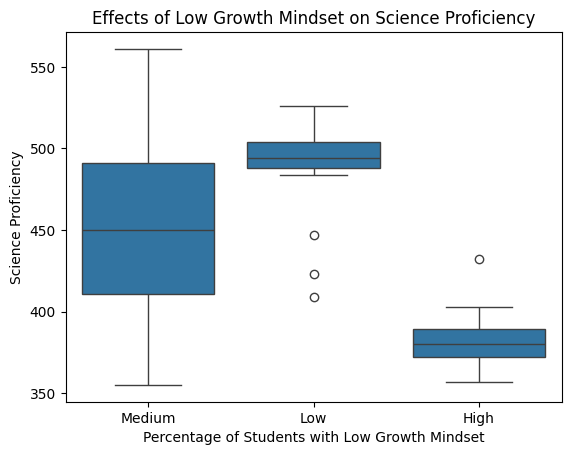

In [89]:
sns.boxplot(data=dfpisa_Q3,x='low_growth_mindset_cat', y='scie_all_mean')
plt.xlabel('Percentage of Students with Low Growth Mindset')
plt.ylabel('Science Proficiency')
plt.title("Effects of Low Growth Mindset on Science Proficiency")
plt.show()

#### **4. How does grit, love of learning and empathy among students influence Science proficiency?**

In [90]:
#Subset to variables of interest
dfpisa_Q4 = pd.DataFrame(dfpisa[["country", "ST307Q02JA_1.0_proportion", "ST307Q02JA_2.0_proportion", "ST307Q02JA_3.0_proportion",
                          "ST307Q02JA_4.0_proportion", "ST307Q02JA_5.0_proportion", "ST301Q10JA_1.0_proportion",
                          "ST301Q10JA_2.0_proportion", "ST301Q10JA_3.0_proportion", "ST301Q10JA_4.0_proportion",
                          "ST301Q10JA_5.0_proportion", "ST303Q04JA_1.0_proportion","ST303Q04JA_2.0_proportion",
                          "ST303Q04JA_3.0_proportion", "ST303Q04JA_4.0_proportion", "ST303Q04JA_5.0_proportion",
                          "math_all_mean", "read_all_mean", "scie_all_mean", 'Geo_Region',
                          'high_grit', 'high_grit_cat', 'low_grit', 'low_grit_cat',
                          'high_love_learn', 'high_love_learn_cat']])

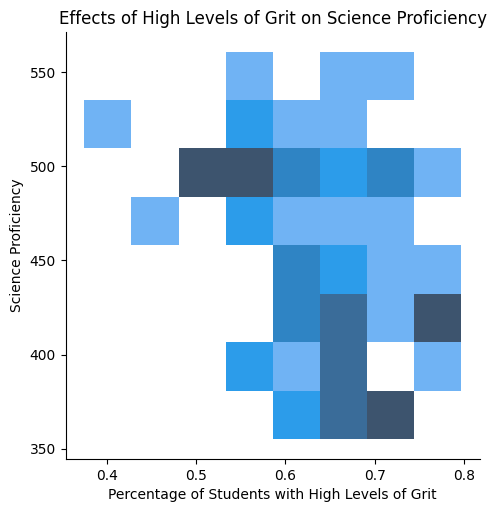

In [91]:
sns.displot(data=dfpisa_Q4, x='high_grit', y='scie_all_mean')
plt.xlabel('Percentage of Students with High Levels of Grit')
plt.ylabel('Science Proficiency')
plt.title("Effects of High Levels of Grit on Science Proficiency")
plt.show()

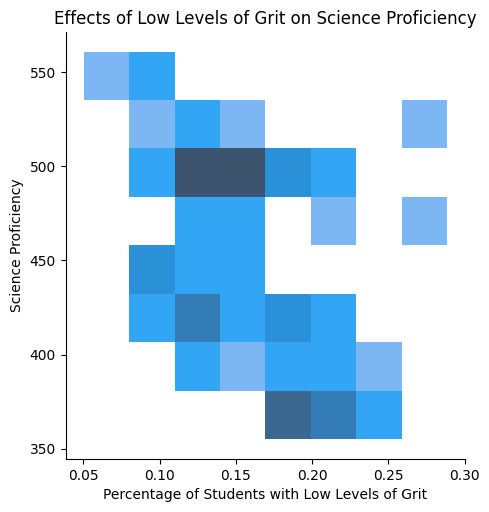

In [92]:
sns.displot(data=dfpisa_Q4, x='low_grit', y='scie_all_mean')
plt.xlabel('Percentage of Students with Low Levels of Grit')
plt.ylabel('Science Proficiency')
plt.title("Effects of Low Levels of Grit on Science Proficiency")
plt.show()

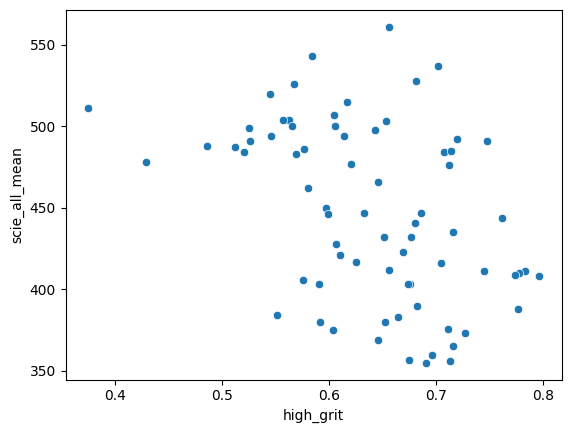

In [93]:
sns.scatterplot(data=dfpisa_Q4,x='high_grit', y='scie_all_mean')
plt.show()

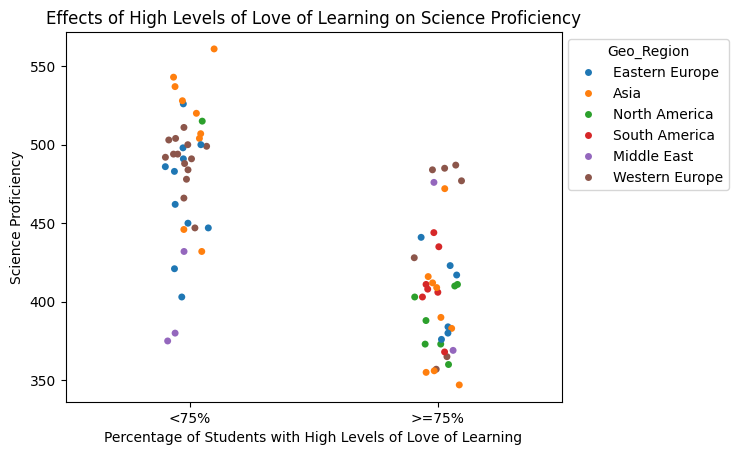

In [94]:
ax = sns.stripplot(data=dfpisa_Q4, x='high_love_learn_cat', y='scie_all_mean',hue='Geo_Region')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.xlabel('Percentage of Students with High Levels of Love of Learning')
plt.ylabel('Science Proficiency')
plt.title("Effects of High Levels of Love of Learning on Science Proficiency")
plt.show()

In [95]:
dfpisa_Q4['high_love_learn_cat'].value_counts()

,count
high_love_learn_cat,
<75%,38
>=75%,38


In [96]:
dfpisa_Q4['high_emp_agg'] = dfpisa_Q4['ST303Q04JA_4.0_proportion']+dfpisa_Q4['ST303Q04JA_5.0_proportion']

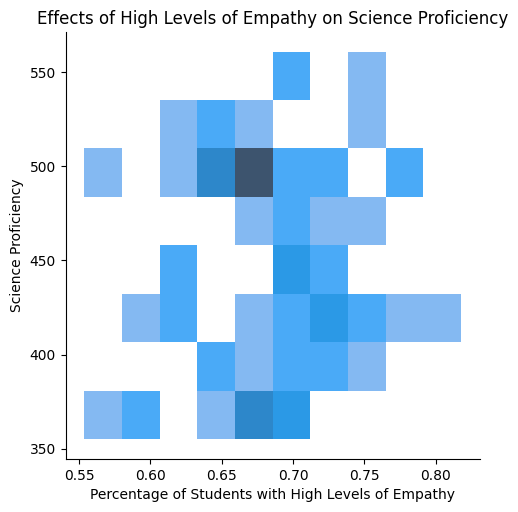

In [97]:
sns.displot(data=dfpisa_Q4, x='high_emp_agg', y='scie_all_mean')
plt.xlabel('Percentage of Students with High Levels of Empathy')
plt.ylabel('Science Proficiency')
plt.title("Effects of High Levels of Empathy on Science Proficiency")
plt.show()

#### **5. What effect does daily moderate to vigorous exercise have on the mental health of students?**


In [98]:
#Subset to variables of interest
dfpisa_Q5 = pd.DataFrame(dfpisa[["country", "WB032Q01NA_1.0_proportion", "WB032Q01NA_2.0_proportion",
                         "WB032Q01NA_3.0_proportion", "WB032Q01NA_4.0_proportion", "WB032Q01NA_5.0_proportion",
                         "WB032Q01NA_6.0_proportion", "WB032Q01NA_7.0_proportion", "WB032Q01NA_8.0_proportion",
                         "WB032Q02NA_1.0_proportion", "WB032Q02NA_2.0_proportion", "WB032Q02NA_3.0_proportion",
                         "WB032Q02NA_5.0_proportion", "WB032Q02NA_5.0_proportion", "WB032Q02NA_6.0_proportion",
                         "WB032Q02NA_7.0_proportion", "WB032Q02NA_8.0_proportion",
                         "WB154Q04HA_1.0_proportion", "WB154Q04HA_2.0_proportion", "WB154Q04HA_3.0_proportion",
                         "WB154Q04HA_4.0_proportion", "WB154Q04HA_5.0_proportion",
                         "WB154Q09HA_1.0_proportion", "WB154Q09HA_2.0_proportion", "WB154Q09HA_3.0_proportion",
                         "WB154Q09HA_4.0_proportion", "WB154Q09HA_5.0_proportion"]])

In [99]:
dfpisa_Q5['enough_exercise'] = dfpisa_Q5['WB032Q01NA_4.0_proportion'] + dfpisa_Q5['WB032Q01NA_5.0_proportion'] + dfpisa_Q5['WB032Q01NA_6.0_proportion']+ dfpisa_Q5['WB032Q01NA_7.0_proportion']+ dfpisa_Q5['WB032Q01NA_8.0_proportion']
exercise_bins = [0, 0.5, 1]
exercise_labels = ['Enough', 'Not Enough']
dfpisa_Q5['enough_exercise_cat'] = pd.cut(dfpisa_Q5['enough_exercise'], bins=exercise_bins, labels=exercise_labels, right=True)

In [100]:
dfpisa_Q5['depress_agg'] = dfpisa_Q5['WB154Q04HA_3.0_proportion'] + dfpisa_Q5['WB154Q04HA_4.0_proportion'] + dfpisa_Q5['WB154Q04HA_5.0_proportion']

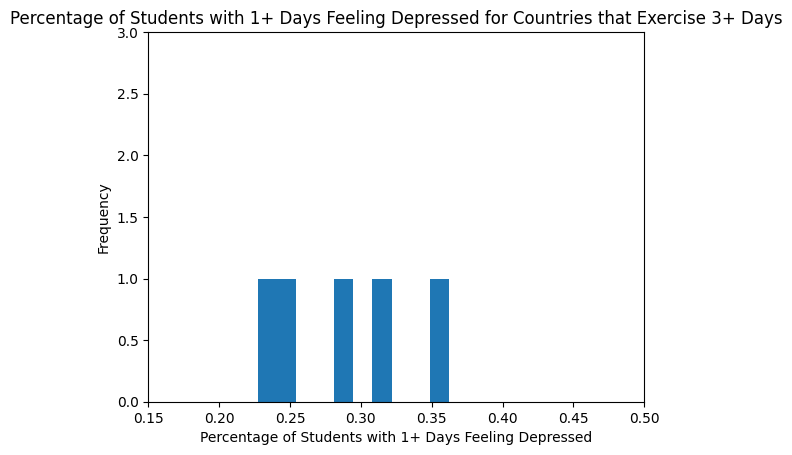

In [101]:
plt.hist(data=dfpisa_Q5[dfpisa_Q5['enough_exercise_cat']=='Enough'],x='depress_agg')
plt.ylim(0,3)
plt.xlim(0.15,0.5)
plt.xlabel('Percentage of Students with 1+ Days Feeling Depressed')
plt.ylabel('Frequency')
plt.title("Percentage of Students with 1+ Days Feeling Depressed for Countries that Exercise 3+ Days")
plt.show()

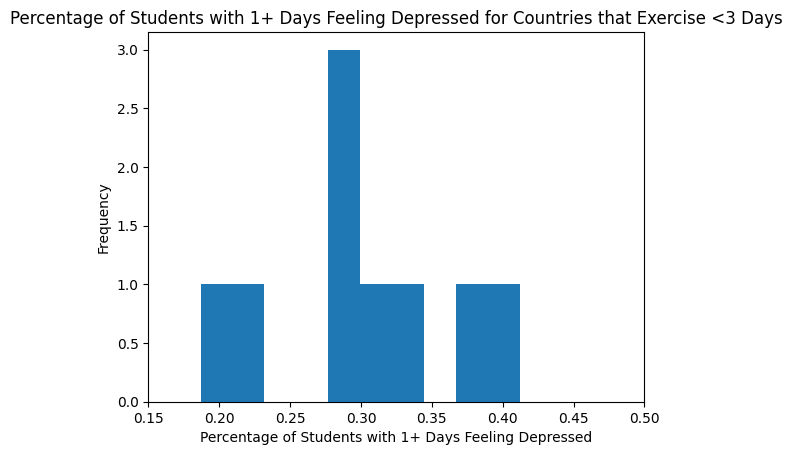

In [102]:
plt.hist(data=dfpisa_Q5[dfpisa_Q5['enough_exercise_cat']=='Not Enough'],x='depress_agg')
plt.xlim(0.15,0.5)
plt.xlabel('Percentage of Students with 1+ Days Feeling Depressed')
plt.ylabel('Frequency')
plt.title("Percentage of Students with 1+ Days Feeling Depressed for Countries that Exercise <3 Days")
plt.show()

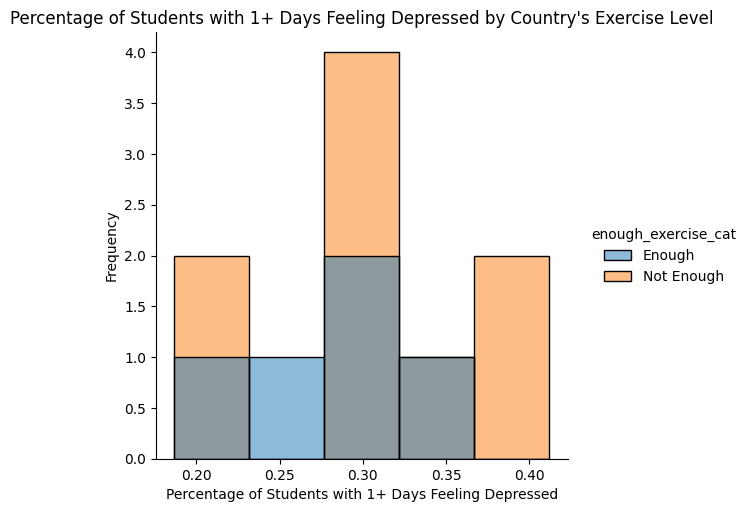

In [103]:
sns.displot(data=dfpisa_Q5, x='depress_agg', hue = 'enough_exercise_cat')
plt.xlabel('Percentage of Students with 1+ Days Feeling Depressed')
plt.ylabel('Frequency')
plt.title("Percentage of Students with 1+ Days Feeling Depressed by Country's Exercise Level")
plt.show()

#### **6. How does total government expenditure on education influence reading and math proficiency?**


In [104]:
#Subset to variables of interest
dfpisa_Q6 = pd.DataFrame(dfpisa[["country", "ed_percent_gdp", "country_gdp",
                                 "math_all_mean", "read_all_mean", "scie_all_mean",
                                 "math_min_proficiency"]])

In [105]:
dfpisa_Q6['ed_percent_gdp'].describe()

,ed_percent_gdp
count,81.000000
mean,4.510049
std,1.154718
min,1.275171
25%,3.738610
50%,4.615470
75%,5.235860
max,7.572200


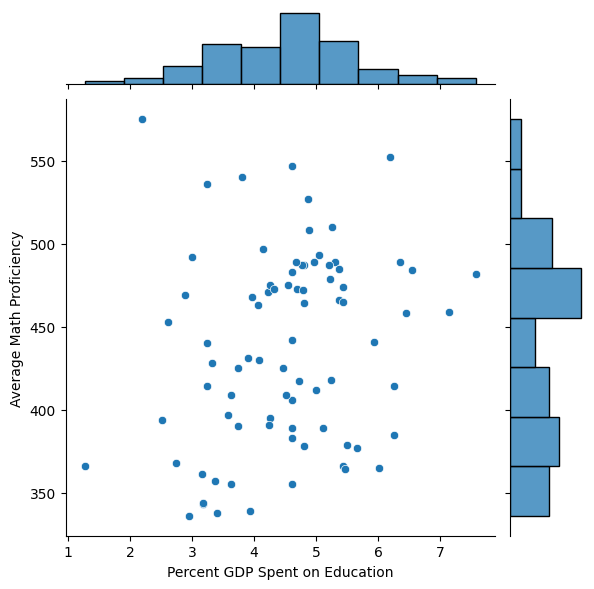

In [106]:
sns.jointplot(data=dfpisa_Q6, x='ed_percent_gdp',y='math_all_mean', palette='bright')
plt.xlabel('Percent GDP Spent on Education')
plt.ylabel('Average Math Proficiency')
plt.show()

In [107]:
#Add variables for partitioned % of GDP spent on education
ed_gdp_bins = [0,3,5,7,8]
ed_gdp_labels = ['1-2%','3-4%','5-6%','7-8%']
#Grouping high love of learning
dfpisa_Q6['ed_percent_gdp_cat'] = pd.cut(dfpisa_Q6['ed_percent_gdp'], bins=ed_gdp_bins, labels=ed_gdp_labels, right=True)

<ipython-input-108-047f2ed8cc28>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dfpisa_Q6, x='ed_percent_gdp_cat', y='math_all_mean', dodge=True, palette='bright')


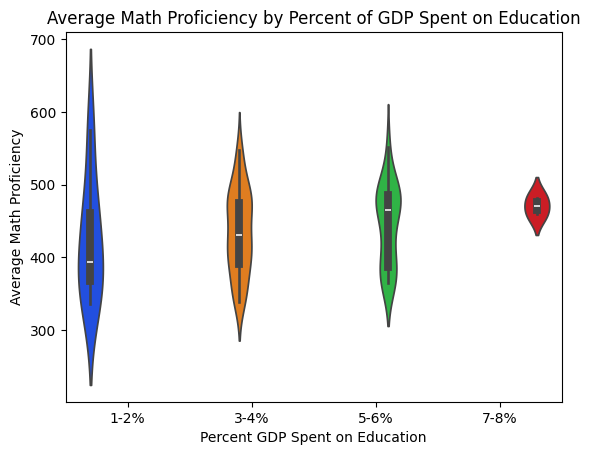

In [108]:
sns.violinplot(data=dfpisa_Q6, x='ed_percent_gdp_cat', y='math_all_mean', dodge=True, palette='bright')
plt.xlabel('Percent GDP Spent on Education')
plt.ylabel('Average Math Proficiency')
plt.title("Average Math Proficiency by Percent of GDP Spent on Education")
plt.show()

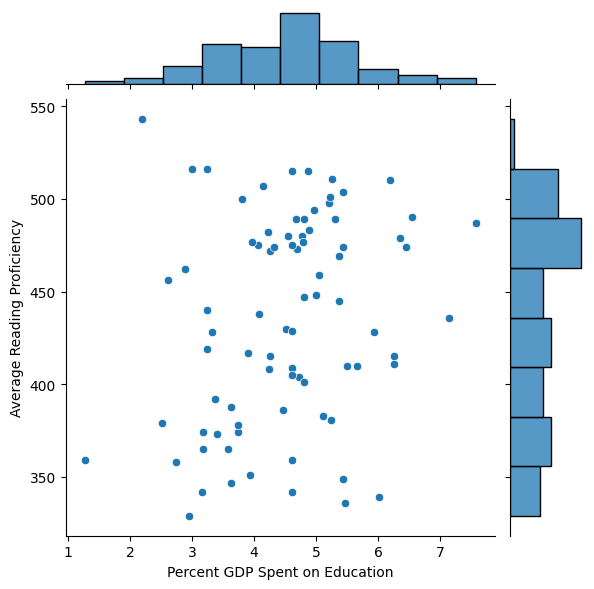

In [109]:
sns.jointplot(data=dfpisa_Q6, x='ed_percent_gdp',y='read_all_mean', palette='bright')
plt.xlabel('Percent GDP Spent on Education')
plt.ylabel('Average Reading Proficiency')
plt.show()

<ipython-input-110-01426429f357>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=dfpisa_Q6, x='ed_percent_gdp_cat', y='read_all_mean', dodge=True, palette='bright')


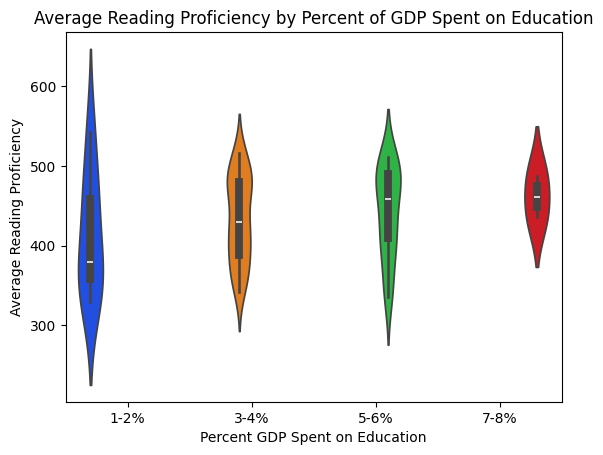

In [110]:
sns.violinplot(data=dfpisa_Q6, x='ed_percent_gdp_cat', y='read_all_mean', dodge=True, palette='bright')
plt.xlabel('Percent GDP Spent on Education')
plt.ylabel('Average Reading Proficiency')
plt.title("Average Reading Proficiency by Percent of GDP Spent on Education")
plt.show()

#### **7. How does food availability affect student performance generally?**


In [111]:
#Subset to variables of interest
dfpisa_Q7 = pd.DataFrame(dfpisa[["country", "ST258Q01JA_1.0_proportion", "ST258Q01JA_2.0_proportion",
                                 "ST258Q01JA_3.0_proportion", "ST258Q01JA_4.0_proportion",
                                 "ST258Q01JA_5.0_proportion",
                                 "math_all_mean", "read_all_mean", "scie_all_mean"]])

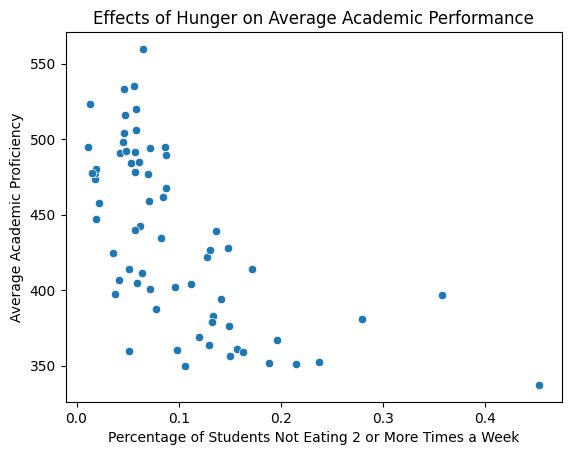

In [112]:
dfpisa_Q7['ST258_3_to_5'] = dfpisa_Q7['ST258Q01JA_3.0_proportion']+dfpisa_Q7['ST258Q01JA_4.0_proportion']+dfpisa_Q7['ST258Q01JA_5.0_proportion']
dfpisa_Q7['average_performance'] = (dfpisa_Q7['math_all_mean']+dfpisa_Q7['read_all_mean']+dfpisa_Q7['scie_all_mean'])/3

sns.scatterplot(data=dfpisa_Q7,x='ST258_3_to_5', y='average_performance')
plt.xlabel('Percentage of Students Not Eating 2 or More Times a Week')
plt.ylabel('Average Academic Proficiency')
plt.title("Effects of Hunger on Average Academic Performance")
plt.show()

#### **8. How does literacy level impact student performance in mathematics?**


In [113]:
#Subset to variables of interest
dfpisa_Q8 = pd.DataFrame(dfpisa[["country", "math_all_mean", "read_all_mean", "scie_all_mean"]])

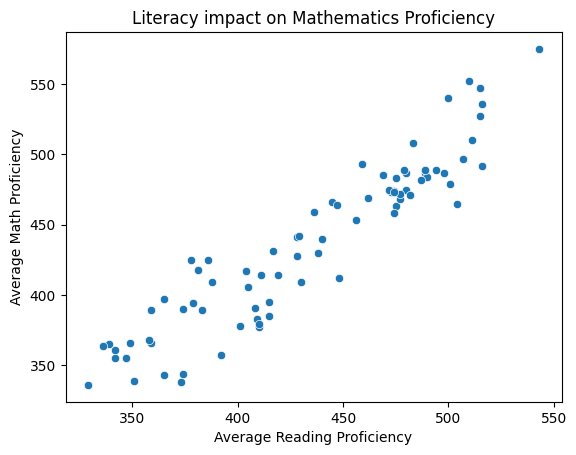

In [114]:
sns.scatterplot(data=dfpisa_Q8,x='read_all_mean', y='math_all_mean')
plt.xlabel('Average Reading Proficiency')
plt.ylabel('Average Math Proficiency')
plt.title("Literacy impact on Mathematics Proficiency")
plt.show()

#### **9. How much of the variation in student performance is explained by socioeconomic status?**


In [115]:
#Subset to variables of interest
dfpisa_Q9 = pd.DataFrame(dfpisa[["country", "ses_all_mean", "math_all_mean", "read_all_mean", "scie_all_mean"]])

In [116]:
dfpisa_Q9['ses_all_mean'].describe()

,ses_all_mean
count,80.000000
mean,-0.357625
std,0.583400
min,-2.010000
25%,-0.735000
50%,-0.245000
75%,0.087500
max,0.520000


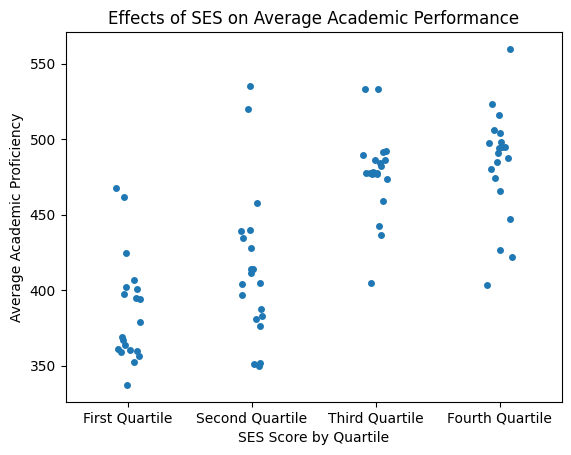

In [117]:
data = dfpisa_Q9['ses_all_mean']
custom_bins = [-2.02, -0.735, -0.245, 0.0875,0.53]
dfpisa_Q9['SES_Bins'] = pd.cut(data, bins=custom_bins, labels=['First Quartile', 'Second Quartile', 'Third Quartile', 'Fourth Quartile'])
dfpisa_Q9['average_performance'] = (dfpisa_Q9['math_all_mean']+dfpisa_Q9['read_all_mean']+dfpisa_Q9['scie_all_mean'])/3

sns.stripplot(data=dfpisa_Q9, x='SES_Bins', y='average_performance')
plt.xlabel('SES Score by Quartile')
plt.ylabel('Average Academic Proficiency')
plt.title("Effects of SES on Average Academic Performance")
plt.show()

#### **10. What impact does socioeconomic status have on school attendance, and which has the greater independent impact on academic performance?**

In [118]:
#Subset to variables of interest
dfpisa_Q10 = pd.DataFrame(dfpisa[["country", "ses_all_mean",
                                  "ST062Q01TA_1.0_proportion", "ST062Q01TA_2.0_proportion",
                                  "ST062Q01TA_3.0_proportion", "ST062Q01TA_4.0_proportion",
                                  "math_all_mean", "read_all_mean", "scie_all_mean"]])

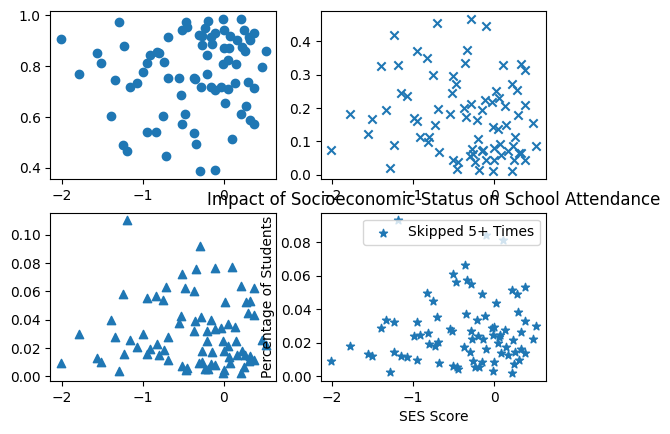

In [119]:
fig, ax = plt.subplots(2, 2)
ax[0,0].scatter(data=dfpisa_Q10,x='ses_all_mean', y='ST062Q01TA_1.0_proportion', label='Never Skipped', marker='o')
ax[0,1].scatter(data=dfpisa_Q10,x='ses_all_mean', y='ST062Q01TA_2.0_proportion', label='Skipped 1-2 Times', marker='x')
ax[1,0].scatter(data=dfpisa_Q10,x='ses_all_mean', y='ST062Q01TA_3.0_proportion', label='Skipped 3-4 Times', marker='^')
ax[1,1].scatter(data=dfpisa_Q10,x='ses_all_mean', y='ST062Q01TA_4.0_proportion', label='Skipped 5+ Times', marker='*')
plt.xlabel('SES Score')
plt.ylabel('Percentage of Students')
plt.title('Impact of Socioeconomic Status on School Attendance')
plt.legend()
plt.show()